In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
days = 365
apartments = 50
residents = int(apartments * 2.2)

dates = pd.date_range(
    start="2025-01-01",
    periods=days
)

data = []

for date in dates:

    is_weekend = date.weekday() >= 5

    laundry_factor = 1.4 if is_weekend else 1.0

    shower = np.random.normal(
        45 * residents,
        6 * residents
    )

    sink = np.random.normal(
        8 * residents,
        2 * residents
    )

    laundry = np.random.normal(
        18 * residents * laundry_factor,
        5 * residents
    )

    toilet = np.random.normal(
        28 * residents,
        4 * residents
    )

    greywater = shower + sink + laundry

    data.append({
        "date": date,
        "greywater_generated": max(greywater, 0),
        "toilet_demand": max(toilet, 0)
    })

df = pd.DataFrame(data)

df.head()

,date,greywater_generated,toilet_demand
0,2025-01-01,8463.641891,3750.133137
1,2025-01-02,8472.515691,3417.671281
2,2025-01-03,7364.630384,2875.078908
3,2025-01-04,7392.068638,2832.593487
4,2025-01-05,7503.252632,2458.586371


In [3]:
tank_capacity = 10000
tank_level = 0

tank_levels = []
freshwater_saved = []
overflow_list = []

for _, row in df.iterrows():

    tank_level += row["greywater_generated"]

    overflow = max(
        tank_level - tank_capacity,
        0
    )

    if overflow > 0:
        tank_level = tank_capacity

    reused = min(
        tank_level,
        row["toilet_demand"]
    )

    tank_level -= reused

    tank_levels.append(tank_level)
    freshwater_saved.append(reused)
    overflow_list.append(overflow)

df["tank_level"] = tank_levels
df["freshwater_saved"] = freshwater_saved
df["overflow"] = overflow_list

df.head()

,date,greywater_generated,toilet_demand,tank_level,freshwater_saved,overflow
0,2025-01-01,8463.641891,3750.133137,4713.508754,3750.133137,0.000000
1,2025-01-02,8472.515691,3417.671281,6582.328719,3417.671281,3186.024445
2,2025-01-03,7364.630384,2875.078908,7124.921092,2875.078908,3946.959103
3,2025-01-04,7392.068638,2832.593487,7167.406513,2832.593487,4516.989729
4,2025-01-05,7503.252632,2458.586371,7541.413629,2458.586371,4670.659145


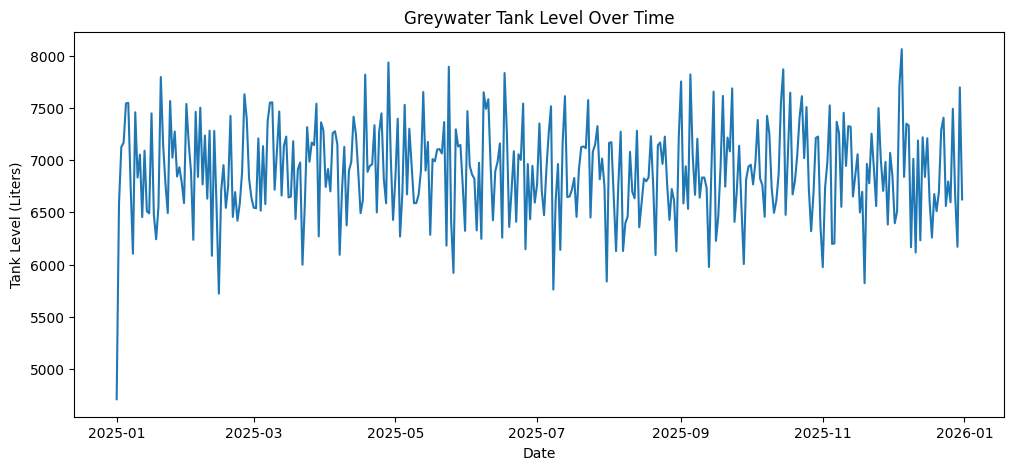

In [4]:
plt.figure(figsize=(12,5))

plt.plot(
    df["date"],
    df["tank_level"]
)

plt.title("Greywater Tank Level Over Time")

plt.xlabel("Date")
plt.ylabel("Tank Level (Liters)")

plt.show()

In [5]:
print("Total Freshwater Saved:")
print(df["freshwater_saved"].sum())

print()

print("Total Overflow:")
print(df["overflow"].sum())

Total Freshwater Saved:
1133581.7874700362

Total Overflow:
1815910.9176756
